In [1]:
import os
import pandas as pd

# Paths
excel_path = 'swing_detection_outputs.xlsx'
output_folder = 'swing_csvs'

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Load Excel
xls = pd.ExcelFile(excel_path)

# Convert each sheet to a CSV file
for sheet_name in xls.sheet_names:
    df = xls.parse(sheet_name)
    filename = f"swings_window_{sheet_name}.csv"
    output_path = os.path.join(output_folder, filename)
    df.to_csv(output_path, index=False)

print(f"✅ Exported {len(xls.sheet_names)} CSV files to folder: {output_folder}")


✅ Exported 10 CSV files to folder: swing_csvs


In [9]:
import os
import glob
import pandas as pd
from backtester_csv import SwingBacktesterWithScaling

# Parameters
csv_folder = 'swing_csvs'
sl_multipliers = [1, 1.5, 2,2.5,3]
summary_rows = []

# Iterate over all CSVs in the folder
csv_files = sorted(glob.glob(os.path.join(csv_folder, "swings_window_*.csv")))

for csv_file in csv_files:
    # Extract window number from filename
    # For 'swings_window_Window_1.csv' → extract the '1'
    window = int(os.path.basename(csv_file).split("_")[-1].replace(".csv", "").replace("Window_", ""))

    print(f"Processing window = {window}")

    for sl_mult in sl_multipliers:
        # Initialize backtester with the DataFrame directly
        df = pd.read_csv(csv_file, parse_dates=True, index_col='timestamp')
        bt = SwingBacktesterWithScaling(data=df, swing_window=window, sl_multiplier=sl_mult)
        
        bt.run_backtest()
        bt.calculate_mae_mfe()
        bt_df = bt.bt.copy()

        if not bt_df.empty:
            total_trades = len(bt_df)
            win_trades = (bt_df['PnL'] > 0).sum()
            win_rate = win_trades / total_trades * 100
            total_pnl = bt_df['PnL'].sum()
            avg_pnl = bt_df['PnL'].mean()
            max_drawdown = (bt_df['Cumulative PnL'].cummax() - bt_df['Cumulative PnL']).max()
            avg_win = bt_df.loc[bt_df['PnL'] > 0, 'PnL'].mean()
            avg_loss = bt_df.loc[bt_df['PnL'] < 0, 'PnL'].mean()
            rr = abs(avg_win) / abs(avg_loss) if avg_loss != 0 else float('inf')
            avg_mae = bt_df['MAE'].mean()
            max_mae = bt_df['MAE'].min()
            avg_mfe = bt_df['MFE'].mean()
            max_mfe = bt_df['MFE'].max()
            winning_pnl = bt_df.loc[bt_df['PnL'] > 0, 'PnL'].sum()
            losing_pnl = bt_df.loc[bt_df['PnL'] < 0, 'PnL'].sum()
            efficiency = (bt_df['PnL'] / bt_df['MFE'].replace(0, float('nan'))) * 100
            avg_efficiency = efficiency.mean()

            summary_rows.append({
                'Window': window,
                'SL Multiplier': sl_mult,
                'Total Trades': total_trades,
                'Win Rate (%)': win_rate,
                'Total PnL': total_pnl,
                'Average PnL': avg_pnl,
                'Max Drawdown': max_drawdown,
                'Risk-Reward': rr,
                'Avg Win': avg_win,
                'Avg Loss': avg_loss,
                'Average MAE': avg_mae,
                'Max MAE': max_mae,
                'Average MFE': avg_mfe,
                'Max MFE': max_mfe,
                'Winning PnL': winning_pnl,
                'Losing PnL': losing_pnl,
                'Avg Trade Efficiency (%)': avg_efficiency
            })

# Final summary DataFrame
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("summary_results.csv", index=False)
print("✅ All results saved to summary_results.csv")

# Optional preview
print(summary_df.head())


Processing window = 1
✅ Total trades generated: 6764
           Entry Time           Exit Time Direction  Entry Price  Exit Price  \
0 2023-06-14 00:35:00 2023-06-14 00:40:00      Long  1945.080000     1944.95   
1 2023-06-14 00:50:00 2023-06-14 01:10:00     Short  1945.060000     1945.54   
2 2023-06-14 03:10:00 2023-06-14 03:20:00      Long  1947.065000     1946.94   
3 2023-06-14 04:50:00 2023-06-14 07:20:00     Short  1947.898571     1946.61   
4 2023-06-14 08:50:00 2023-06-14 08:55:00      Long  1950.355000     1949.30   

    PnL Exit Reason  SL Price  Units  
0 -0.13      SL Hit   1944.95      1  
1 -0.48      SL Hit   1945.54      1  
2 -0.25      SL Hit   1946.94      2  
3  9.02      SL Hit   1946.61      7  
4 -2.11      SL Hit   1949.30      2  
✅ Total trades generated: 6648
           Entry Time           Exit Time Direction  Entry Price  Exit Price  \
0 2023-06-14 00:35:00 2023-06-14 00:40:00      Long  1945.080000    1944.885   
1 2023-06-14 00:50:00 2023-06-14 01:15:00

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary results
df = pd.read_csv(r"Parameters Comparison Summary\summary_results.csv")

# Preview the data structure
print(df.head())


   Window  SL Multiplier  Total Trades  Win Rate (%)  Total PnL  Average PnL  \
0       1            1.0          6764     24.068598    8384.16     1.239527   
1       1            1.5          6648     25.541516    8726.19     1.312604   
2       1            2.0          6573     26.776206    8912.49     1.355924   
3       1            2.5          6523     27.579335    8909.77     1.365901   
4       1            3.0          6479     28.214231    8925.09     1.377541   

   Max Drawdown  Risk-Reward   Avg Win  Avg Loss  Average MAE  Max MAE  \
0        51.080     8.284489  7.834122 -0.945637     0.158313  -54.955   
1        59.055     7.136919  8.112839 -1.136742     0.169847  -54.955   
2        64.160     6.388458  8.211659 -1.285390     0.177301  -54.955   
3        72.800     5.863788  8.262752 -1.409115     0.182513  -54.955   
4        79.170     5.490116  8.331975 -1.517632     0.171885  -54.955   

   Average MFE    Max MFE  Winning PnL  Losing PnL  Avg Trade Efficiency (

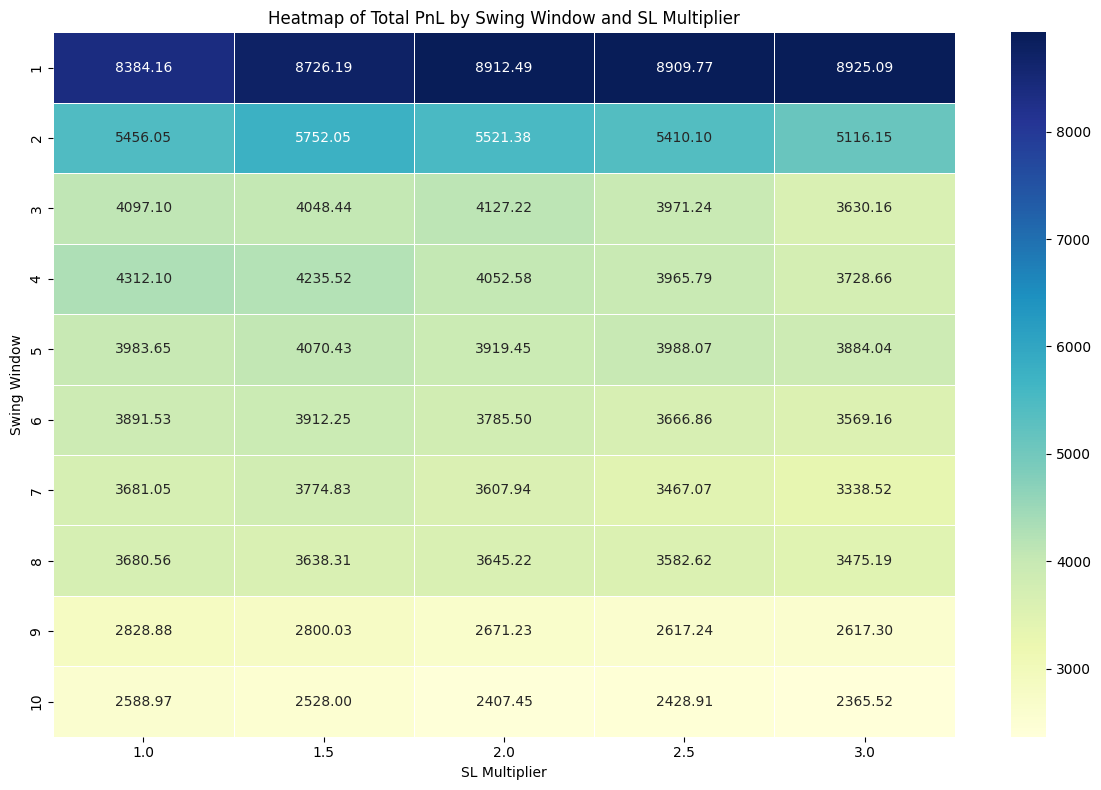

In [14]:
# Pivot the DataFrame to make it suitable for a heatmap
heatmap_data = df.pivot(index='Window', columns='SL Multiplier', values='Total PnL')

# Sort the axes for better readability
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)


# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Total PnL by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


In [ ]:
# Pivot the DataFrame to make it suitable for a heatmap
df['']

heatmap_data = df.pivot(index='Window', columns='SL Multiplier', values='Total PnL')

# Sort the axes for better readability
heatmap_data = heatmap_data.sort_index().sort_index(axis=1)


# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Total PnL by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


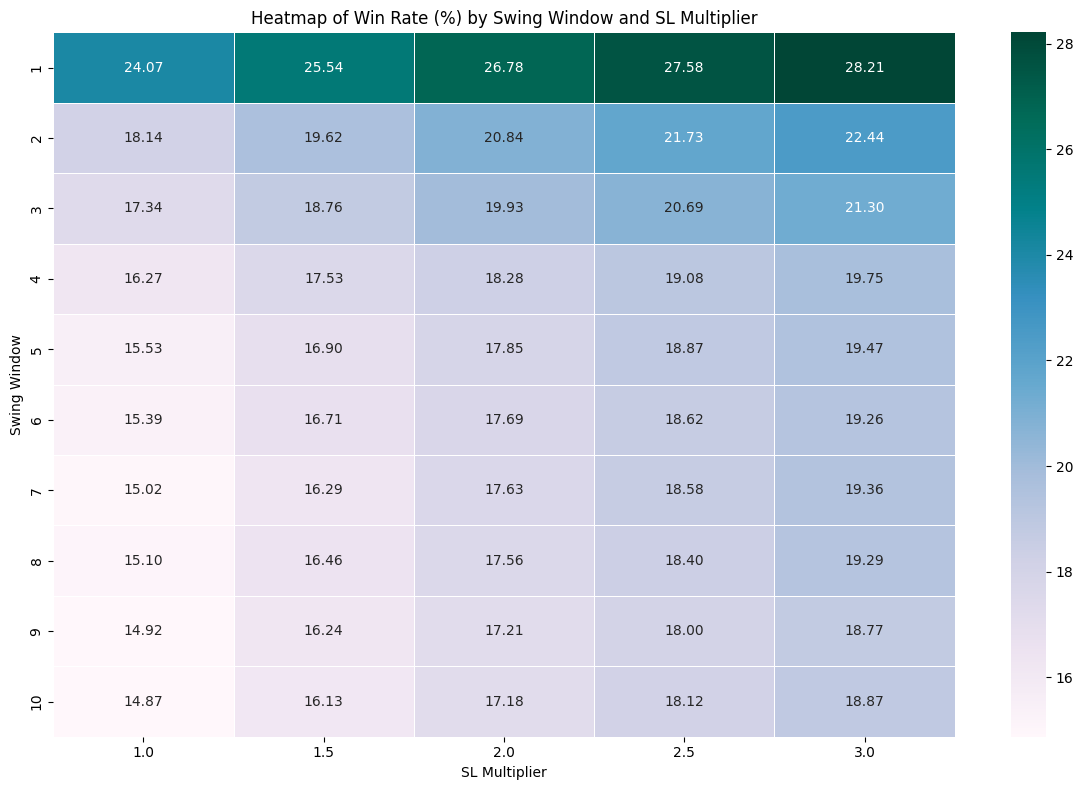

In [15]:
plt.figure(figsize=(12, 8))
win_rate_data = df.pivot(index='Window', columns='SL Multiplier', values='Win Rate (%)')
win_rate_data = win_rate_data.sort_index().sort_index(axis=1)
sns.heatmap(win_rate_data, annot=True, fmt=".2f", cmap="PuBuGn", linewidths=.5)
plt.title("Heatmap of Win Rate (%) by Swing Window and SL Multiplier")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


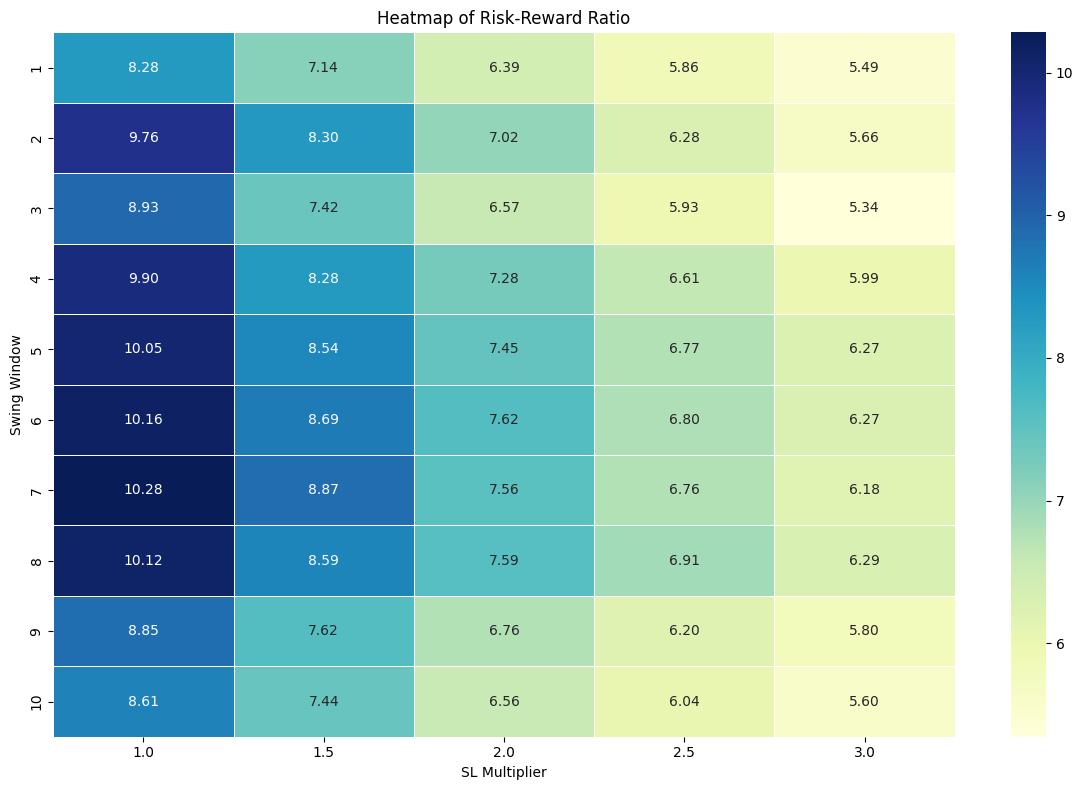

In [16]:
plt.figure(figsize=(12, 8))
rr_data = df.pivot(index='Window', columns='SL Multiplier', values='Risk-Reward')
rr_data = rr_data.sort_index().sort_index(axis=1)
sns.heatmap(rr_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Risk-Reward Ratio")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


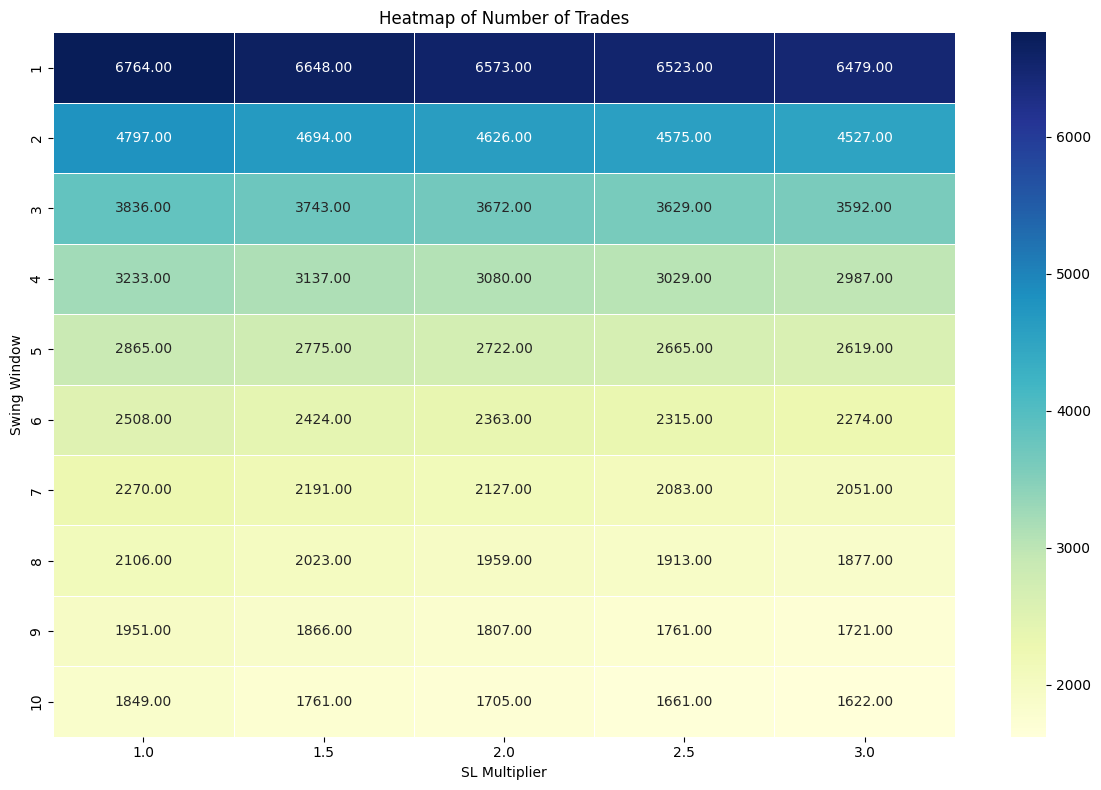

In [17]:
plt.figure(figsize=(12, 8))
rr_data = df.pivot(index='Window', columns='SL Multiplier', values='Total Trades')
rr_data = rr_data.sort_index().sort_index(axis=1)
sns.heatmap(rr_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Number of Trades")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


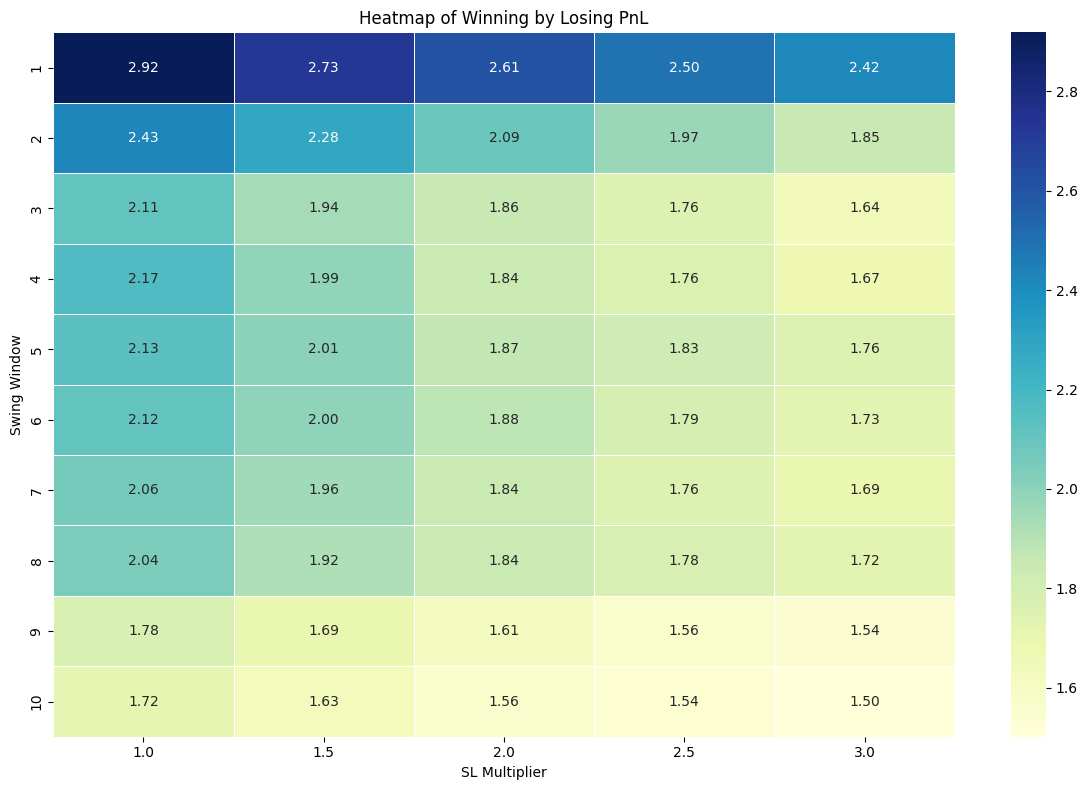

In [18]:
df['Winning/Losing PnL'] = abs(df['Winning PnL']/df['Losing PnL'])
plt.figure(figsize=(12, 8))
rr_data = df.pivot(index='Window', columns='SL Multiplier', values='Winning/Losing PnL')
rr_data = rr_data.sort_index().sort_index(axis=1)
sns.heatmap(rr_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Winning by Losing PnL")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()


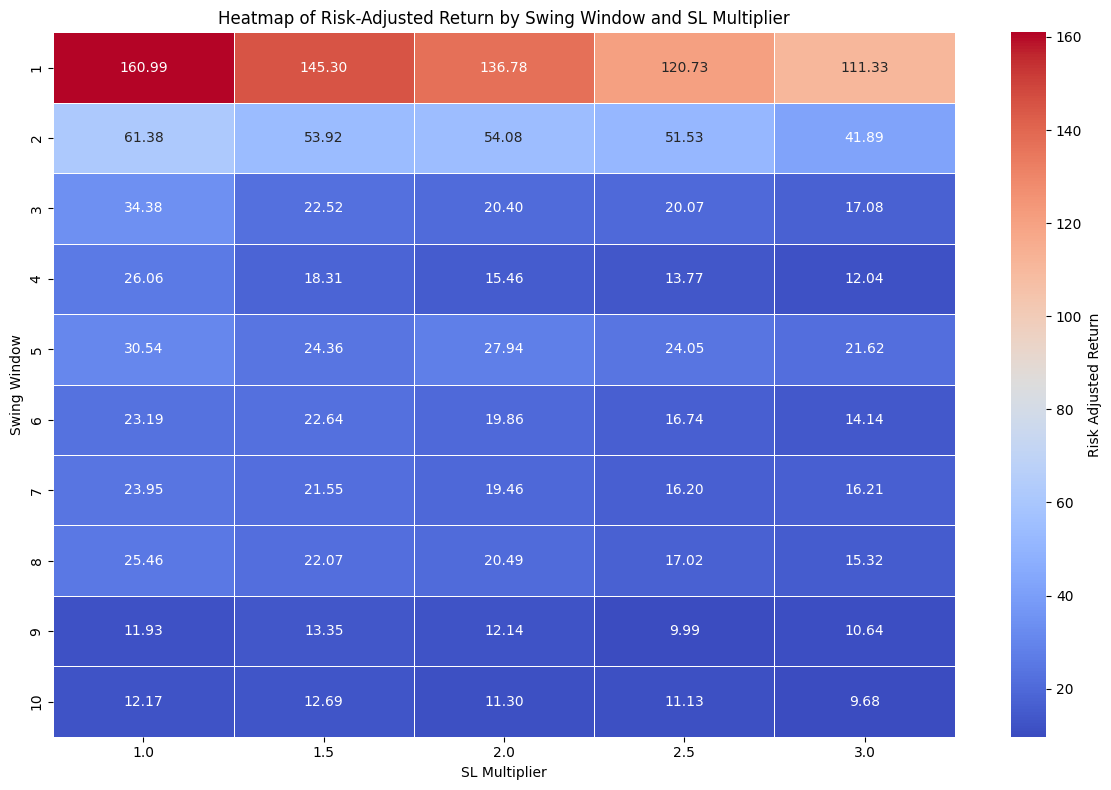

In [25]:

# Compute Risk-Adjusted Return (RAR)
df['RiskAdjustedReturn'] = (df['Total PnL'] / (1 + df['Max Drawdown']))

# Pivot for heatmap
pivot_rar = df.pivot(index='Window', columns='SL Multiplier', values='RiskAdjustedReturn')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_rar, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, cbar_kws={'label': 'Risk Adjusted Return'})
plt.title('Heatmap of Risk-Adjusted Return by Swing Window and SL Multiplier')
plt.xlabel('SL Multiplier')
plt.ylabel('Swing Window')
plt.tight_layout()
plt.show()


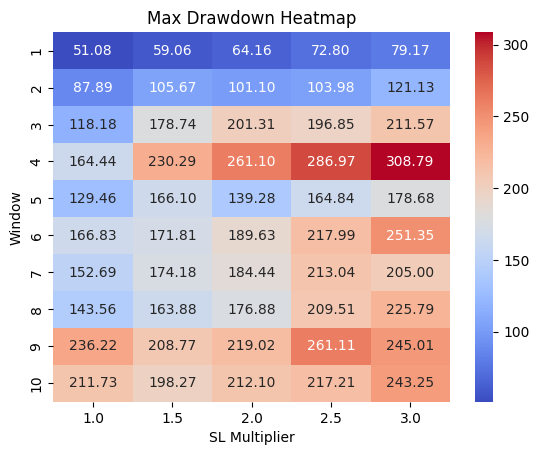

In [20]:
pivot_drawdown = df.pivot(index='Window', columns='SL Multiplier', values='Max Drawdown')
sns.heatmap(pivot_drawdown, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Max Drawdown Heatmap')
plt.show()


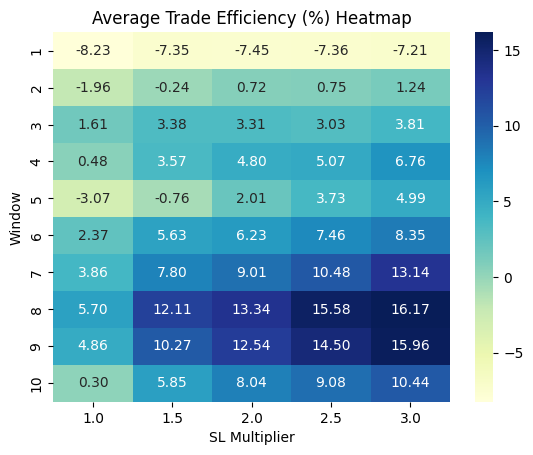

In [12]:
pivot_eff = df.pivot(index='Window', columns='SL Multiplier', values='Avg Trade Efficiency (%)')
sns.heatmap(pivot_eff, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Average Trade Efficiency (%) Heatmap')
plt.show()


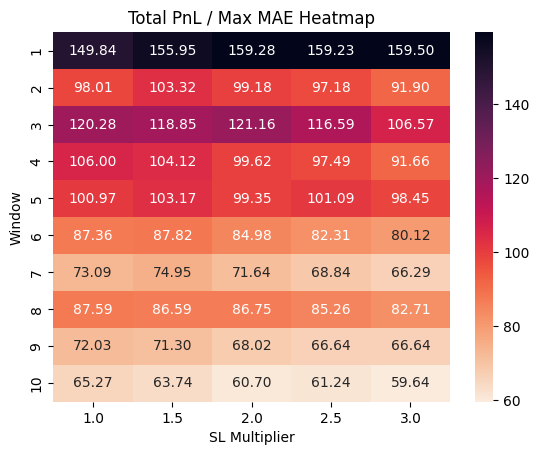

In [22]:
df['PnL_to_MAE'] = df['Total PnL'] / (1 + abs(df['Max MAE']))
pivot_pnl_mae = df.pivot(index='Window', columns='SL Multiplier', values='PnL_to_MAE')
sns.heatmap(pivot_pnl_mae, annot=True, fmt=".2f", cmap='rocket_r')
plt.title('Total PnL / Max MAE Heatmap')
plt.show()


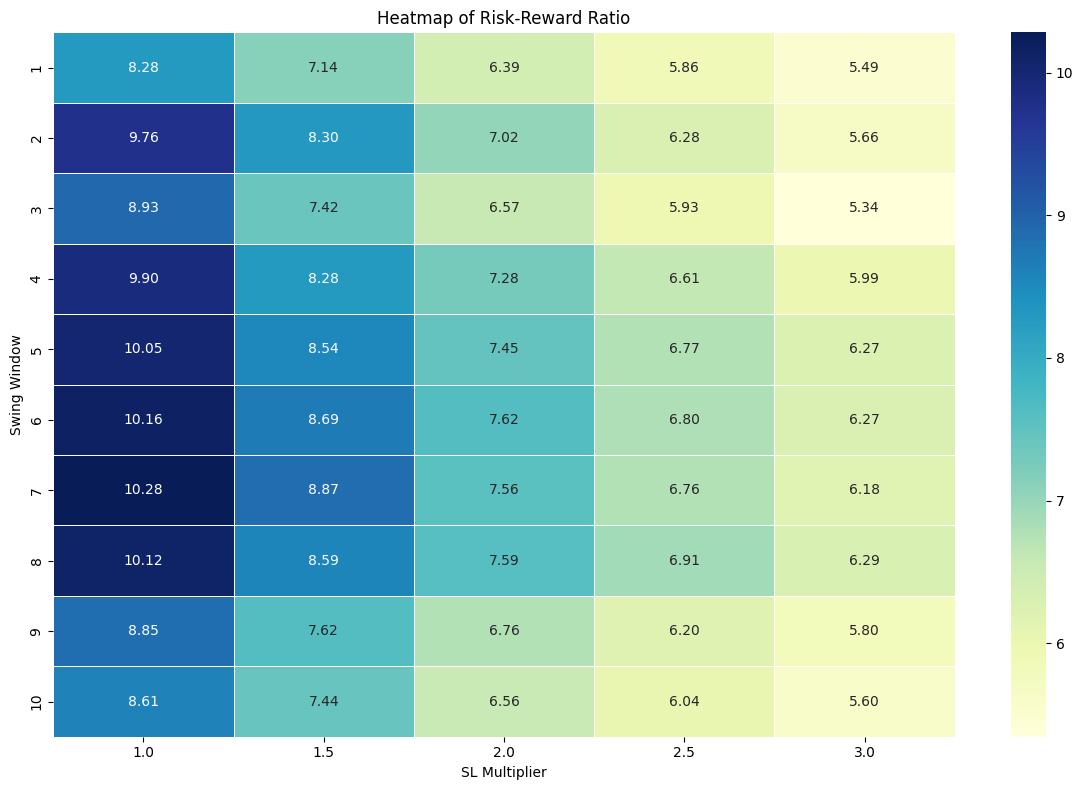

In [26]:
df['PnL per Unit']= df['Total PnL']/df['']

plt.figure(figsize=(12, 8))
rr_data = df.pivot(index='Window', columns='SL Multiplier', values='Risk-Reward')
rr_data = rr_data.sort_index().sort_index(axis=1)
sns.heatmap(rr_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Risk-Reward Ratio")
plt.xlabel("SL Multiplier")
plt.ylabel("Swing Window")
plt.tight_layout()
plt.show()
